In [5]:
import cv2
import re
import json
import numpy as np
import pytesseract
from graphviz import Digraph
import matplotlib.pyplot as plt

In [6]:
image_path = "uml_sample.png"   

image = cv2.imread(image_path)

if image is None:
    print(" Image not found")
else:
    print(" Image successfully loaded")


 Image successfully loaded


(np.float64(-0.5), np.float64(775.5), np.float64(499.5), np.float64(-0.5))

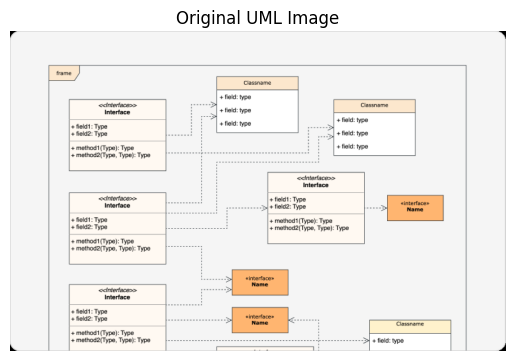

In [4]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original UML Image")
plt.axis("off")


(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

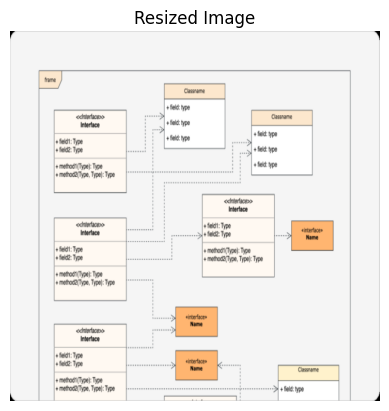

In [7]:
resized_image = cv2.resize(image, (800, 800))

plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")


In [8]:
image = cv2.imread("uml_sample.png")


In [9]:
print(image.shape)


(500, 776, 3)


(np.float64(-0.5), np.float64(775.5), np.float64(499.5), np.float64(-0.5))

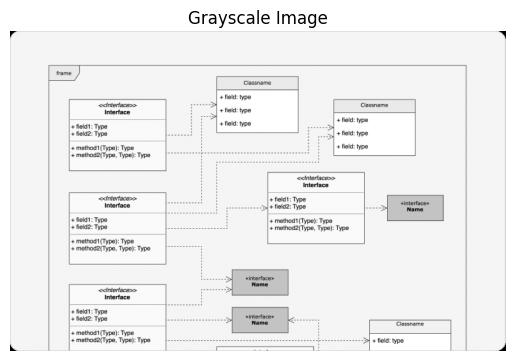

In [10]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


(np.float64(-0.5), np.float64(775.5), np.float64(499.5), np.float64(-0.5))

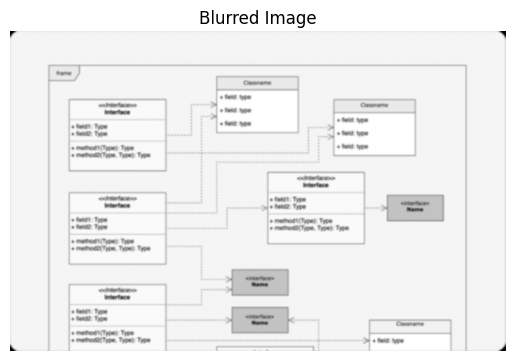

In [11]:
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

plt.imshow(blurred_image, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")


(np.float64(-0.5), np.float64(775.5), np.float64(499.5), np.float64(-0.5))

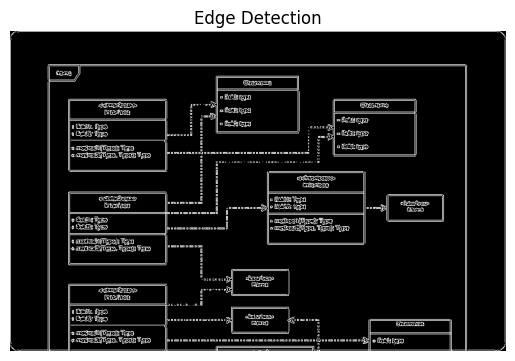

In [12]:
edges = cv2.Canny(gray_image, 50, 150)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")


In [13]:
# Find contours from edge image
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Total contours found:", len(contours))


Total contours found: 428


(np.float64(-0.5), np.float64(775.5), np.float64(499.5), np.float64(-0.5))

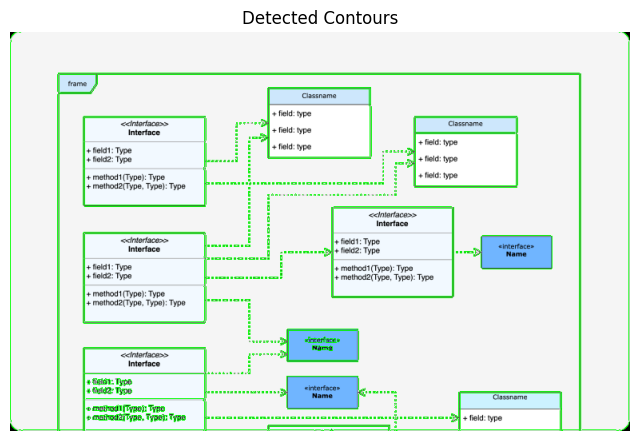

In [14]:
# Copy original image for drawing
contour_image = image.copy()

# Draw all contours
cv2.drawContours(
    contour_image,
    contours,
    -1,
    (0, 255, 0),   # green color
    1
)

plt.figure(figsize=(8,6))
plt.imshow(contour_image)
plt.title("Detected Contours")
plt.axis("off")


In [15]:
# Filter only rectangular contours
rectangles = []

for cnt in contours:
    # Approximate contour shape
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    # Rectangle has 4 corners
    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)

        # Remove very small boxes (noise)
        if w > 50 and h > 30:
            rectangles.append((x, y, w, h))

print("Detected UML-like boxes:", len(rectangles))



Detected UML-like boxes: 5


(np.float64(-0.5), np.float64(775.5), np.float64(499.5), np.float64(-0.5))

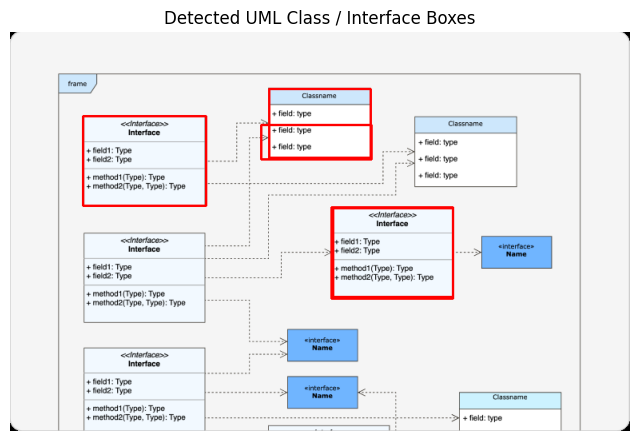

In [16]:
# Draw only detected UML boxes
box_image = image.copy()

for (x, y, w, h) in rectangles:
    cv2.rectangle(
        box_image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),   # Blue boxes
        2
    )

plt.figure(figsize=(8,6))
plt.imshow(box_image)
plt.title("Detected UML Class / Interface Boxes")
plt.axis("off")


In [17]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Image load
image = cv2.imread("uml_sample.png")

# OpenCV reads BGR → convert to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# OCR
text = pytesseract.image_to_string(image_rgb)

print("===== EXTRACTED TEXT =====")
print(text)


===== EXTRACTED TEXT =====
+ method (Type): Type
+ method2CType, Type): Type

‘fed ype

++ ft: ype

Clssname

+f: ype

Interface

+ felat: Type
+62: Type

sme 99)
aoe. Te

Heat: Type
+ lee: Typo

+ method (Type): Type
+ method2CType, Type): Type

“+e: ype
+f: ype
+l: ype

“<cnterfacas>
Interface

felt: Type
fee: Type

|+ methoat (ype): Type

‘+ method2{Type, Type): Type




In [18]:

cleaned_lines = []
seen_interface = False

for line in text.split("\n"):
    line = line.strip()

    # Skip empty / very small junk
    if len(line) < 3:
        continue

    # Fix common OCR mistakes
    line = line.replace("Clss", "Class")

    # Normalize interface (keep only once)
    if "interface" in line.lower():
        if not seen_interface:
            cleaned_lines.append("Interface")
            seen_interface = True
        continue

    # Keep attributes & methods
    if line.startswith("+") or line.startswith("-"):
        cleaned_lines.append(line)
        continue

    # Keep only valid class-like names (letters only)
    if re.match(r"^[A-Za-z][A-Za-z ]{2,}$", line):
        cleaned_lines.append(line)

# Preview
for l in cleaned_lines:
    print(l)


+ method (Type): Type
+ method2CType, Type): Type
++ ft: ype
Classname
+f: ype
Interface
+ felat: Type
+62: Type
+ lee: Typo
+ method (Type): Type
+ method2CType, Type): Type
+f: ype
+l: ype


In [19]:
classes = []
interfaces = []

current_block = None

for line in cleaned_lines:

    # ---- INTERFACE ----
    if line == "Interface":
        current_block = {
            "type": "interface",
            "name": "Interface",
            "attributes": [],
            "methods": []
        }
        interfaces.append(current_block)
        continue

    # ---- CLASS NAME ----
    if not line.startswith("+") and "(" not in line and ":" not in line:
        current_block = {
            "type": "class",
            "name": line,
            "attributes": [],
            "methods": []
        }
        classes.append(current_block)
        continue

    # ---- METHOD (CHECK FIRST) ----
    if line.startswith("+") and "(" in line:
        if current_block:
            current_block["methods"].append(line)
        continue

    # ---- ATTRIBUTE ----
    if line.startswith("+") and ":" in line:
        if current_block:
            current_block["attributes"].append(line)


In [20]:
for c in classes:
    print("CLASS:", c["name"])
    print(" Attributes:", c["attributes"])
    print(" Methods:", c["methods"])
    print("-"*40)

for i in interfaces:
    print("INTERFACE:", i["name"])
    print(" Attributes:", i["attributes"])
    print(" Methods:", i["methods"])
    print("-"*40)


CLASS: Classname
 Attributes: ['+f: ype']
 Methods: []
----------------------------------------
INTERFACE: Interface
 Attributes: ['+ felat: Type', '+62: Type', '+ lee: Typo', '+ method2CType, Type): Type', '+f: ype', '+l: ype']
 Methods: ['+ method (Type): Type']
----------------------------------------


In [ ]:
# ==============================
# STEP-3: Build UML Output
# ==============================

uml_output = {
    "classes": [],
    "relationships": []
}

# Add classes
for c in classes:
    uml_output["classes"].append({
        "name": c["name"],
        "type": "class",
        "attributes": c["attributes"],
        "methods": c["methods"]
    })

# Add interfaces
for i in interfaces:
    uml_output["classes"].append({
        "name": i["name"],
        "type": "interface",
        "attributes": i["attributes"],
        "methods": i["methods"]
    })

# Debug check (optional but recommended)
print("UML CLASSES:")
for c in uml_output["classes"]:
    print("-", c["name"], "(", c["type"], ")")


In [ ]:
# ==============================
# STEP-4: Relationship Detection
# ==============================

relationships = []

# Class implements Interface
for c in classes:
    for i in interfaces:
        relationships.append({
            "from": c["name"],
            "to": i["name"],
            "type": "implements"
        })

uml_output["relationships"] = relationships

# Preview
for r in relationships:
    print(r)


In [ ]:
def draw_uml(uml_output):
    dot = Digraph(comment="UML Class Diagram", format="png")
    dot.attr(rankdir="TB", fontsize="12")

    for c in uml_output["classes"]:
        # ---- Build record-style label ----
        name = c["name"]

        if c["type"] == "interface":
            name = "\\<\\<interface\\>\\>\\n" + name

        attrs = "\\l".join(c["attributes"]) + "\\l" if c["attributes"] else ""
        meths = "\\l".join(c["methods"]) + "\\l" if c["methods"] else ""

        label = "{%s|%s|%s}" % (name, attrs, meths)

        dot.node(c["name"], label=label, shape="record")

    # ---- Relationships ----
    for r in uml_output["relationships"]:
        if r["type"] == "implements":
            dot.edge(r["from"], r["to"], label="implements", style="dashed")
        elif r["type"] == "association":
            dot.edge(r["from"], r["to"], label="association")

    return dot


In [ ]:
uml_diagram = draw_uml(uml_output)
uml_diagram
